# ДЗ 13: Классификация текста с использованием BERT

## Анализ датасета Emotion и дообучение модели
В этом ноутбуке демонстрируется процесс токенизации, анализ базовой модели и тонкая настройка (fine-tuning) модели BERT для классификации текста.


## Блок 1: Импорт библиотек и настройка окружения

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline
)
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report


*Настройка random seed и выбор устройства (CPU/GPU).*

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.environ['PYTHONHASHSEED'] = str(SEED)


## Блок 2: Информация о датасете
### 2.1 Загрузка данных и проверка

*Загрузка датасета Emotion и определение конфигурации меток.*

In [ ]:
dataset = load_dataset('emotion')
# Для быстрого обучения на CPU
for split in dataset.keys():
    dataset[split] = dataset[split].select(range(min(200, len(dataset[split]))))

id2label = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}
label2id = {v: k for k, v in id2label.items()}

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
# Печать размеров выборок и примеров данных
print("Размеры датасетов:")
for split in dataset.keys():
    print(f"  {split}: {len(dataset[split])} примеров")

print("\nПримеры текстов и их метки:")
for i in range(5):
    item = dataset['train'][i]
    print(f"Текст {i+1}: {item['text']}")
    print(f"Метка {i+1}: {id2label[item['label']]} (ID: {item['label']})\n")

Размеры датасетов:
  train: 200 примеров
  validation: 200 примеров
  test: 200 примеров

Примеры текстов и их метки:
Текст 1: i didnt feel humiliated
Метка 1: sadness (ID: 0)

Текст 2: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Метка 2: sadness (ID: 0)

Текст 3: im grabbing a minute to post i feel greedy wrong
Метка 3: anger (ID: 3)

Текст 4: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Метка 4: love (ID: 2)

Текст 5: i am feeling grouchy
Метка 5: anger (ID: 3)



Этот датасет классифицирует англоязычные тексты (в основном твиты) на 6 эмоциональных категорий: `sadness`, `joy`, `love`, `anger`, `fear`, `surprise`. Цель задачи — определить, какую эмоцию выражает автор текста.

*Анализ распределения классов тренировочной, валидационной и тестовой выборок.*

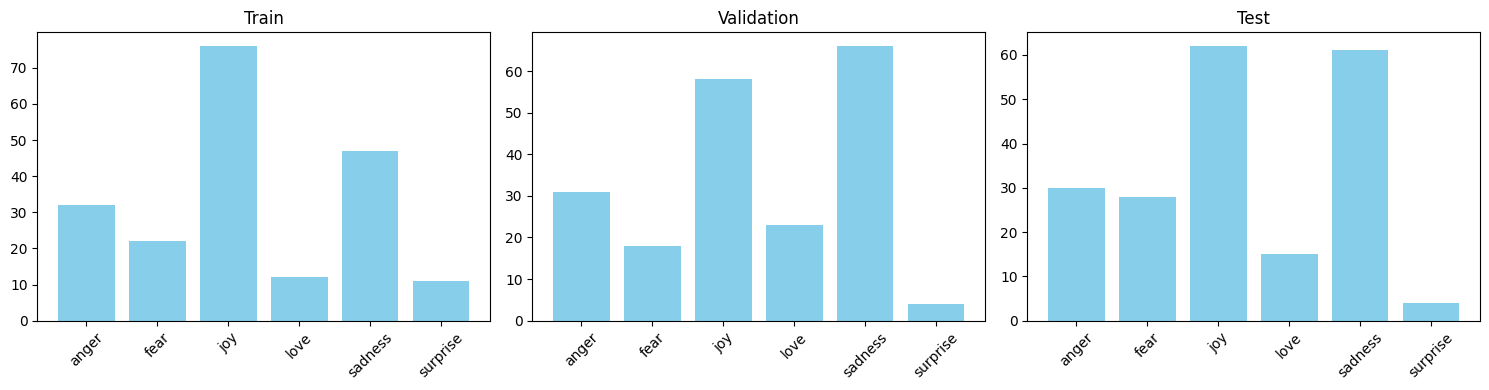

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, split_name in enumerate(['train', 'validation', 'test']):
    labels = [item['label'] for item in dataset[split_name]]
    emotions = [id2label[l] for l in labels]
    emotion_counts = pd.Series(emotions).value_counts().sort_index()
    axes[idx].bar(emotion_counts.index, emotion_counts.values, color='skyblue')
    axes[idx].set_title(f'{split_name.capitalize()}')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
os.makedirs('artifacts', exist_ok=True)
plt.savefig('artifacts/class_distribution.png')
plt.show()


### 2.2 Анализ токенизации

*Инициализация токенизатора DistilBERT.*

In [6]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

*Демонстрация генерации id токенов и маски внимания (attention mask) для примера текста.*

In [7]:
sample_text = dataset['train'][0]['text']
encoding_padded = tokenizer(
    sample_text,
    return_tensors='pt',
    padding='max_length',
    max_length=50,
    truncation=True
)

print(f"Sample text: {sample_text}")
print(f"Input IDs shape: {encoding_padded['input_ids'].shape}")


Sample text: i didnt feel humiliated
Input IDs shape: torch.Size([1, 50])


In [ ]:
# Разбор токенизации еще на нескольких примерах (демонстрация padding/truncation, attention_mask, special tokens)
examples = dataset['train'][:3]['text']
tokenized_examples = tokenizer(
    examples,
    return_tensors='pt',
    padding='max_length',
    max_length=20,
    truncation=True
)

for i in range(len(examples)):
    print(f"Текст {i+1}: {examples[i]}")
    tokens = tokenizer.convert_ids_to_tokens(tokenized_examples['input_ids'][i])
    print(f"  Токены: {tokens}")
    print(f"  input_ids: {tokenized_examples['input_ids'][i].tolist()}")
    print(f"  attention_mask: {tokenized_examples['attention_mask'][i].tolist()}")
    print("-" * 50)

print("\nSpecial tokens:", tokenizer.special_tokens_map)

Текст 1: i didnt feel humiliated
  Токены: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
  input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  attention_mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
--------------------------------------------------
Текст 2: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
  Токены: ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', '[SEP]']
  input_ids: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 102]
  attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
--------------------------------------------

## Блок 3: Обучение и инференс моделей
### 3.1 Инференс с помощью предобученной модели

*Использование pipeline (анализ тональности) с предобученной моделью DistilBERT.*

In [9]:
classifier_pipeline = pipeline('sentiment-analysis', model="distilbert-base-uncased-finetuned-sst-2-english", device=0 if torch.cuda.is_available() else -1)

sample_texts = dataset['train'][:3]['text']
for text in sample_texts:
    pred = classifier_pipeline(text[:512])[0]
    print(f"Text: {text} | Pred: {pred['label']} ({pred['score']:.2f})")


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Text: i didnt feel humiliated | Pred: POSITIVE (0.89)
Text: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake | Pred: POSITIVE (0.97)
Text: im grabbing a minute to post i feel greedy wrong | Pred: NEGATIVE (1.00)


Предобученная модель `distilbert-base-uncased-finetuned-sst-2-english` анализирует тональность (позитив/негатив), но не различает 6 конкретных эмоций (вместо `sadness` или `love` она выдает `NEGATIVE` или `POSITIVE`). Поэтому такая модель не подходит под задачу классификации эмоций на 6 классов без ее предварительного обучения (fine-tuning).

### 3.2 Дообучение BERT для классификации эмоций

*Токенизация частей датасета для дообучения модели.*

In [10]:
def preprocess_function(examples):
    return tokenizer(examples['text'], padding='max_length', max_length=128, truncation=True)

tokenized_datasets = dataset.map(preprocess_function, batched=True, remove_columns=['text'])
for split in tokenized_datasets.keys():
    tokenized_datasets[split] = tokenized_datasets[split].rename_column('label', 'labels')
    tokenized_datasets[split].set_format('torch')


Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

*Загрузка модели DistilBERT для классификации последовательностей, настроенной на 6 целевых классов эмоций.*

In [11]:
model_checkpoint = 'distilbert-base-uncased'
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=6,
    id2label=id2label,
    label2id=label2id
).to(device)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


*Определение функции метрик для аргументов конфигурации Trainer.*

In [12]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_macro': f1_score(labels, predictions, average='macro')
    }

training_args = TrainingArguments(
    output_dir='./fine_tuned_model',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    seed=SEED,
)


*Обучение инициализированной модели DistilBERT.*

In [13]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    compute_metrics=compute_metrics,
)

train_result = trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,1.645810,0.315000,0.099866


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


### 3.3 Оценка модели на тестовой выборке

*Запуск финальной оценки для расчета accuracy, F1-score и получения отчета о классификации.*

In [14]:
predictions_test = trainer.predict(tokenized_datasets['test'])
pred_labels_test = np.argmax(predictions_test.predictions, axis=1)
true_labels_test = predictions_test.label_ids

print(classification_report(true_labels_test, pred_labels_test, target_names=[id2label[i] for i in range(6)]))


              precision    recall  f1-score   support

     sadness       0.50      0.08      0.14        61
         joy       0.32      0.98      0.48        62
        love       0.00      0.00      0.00        15
       anger       0.00      0.00      0.00        30
        fear       0.00      0.00      0.00        28
    surprise       0.00      0.00      0.00         4

    accuracy                           0.33       200
   macro avg       0.14      0.18      0.10       200
weighted avg       0.25      0.33      0.19       200



*Визуализация матрицы ошибок на тестовых предсказаниях для наглядного анализа ошибок модели.*

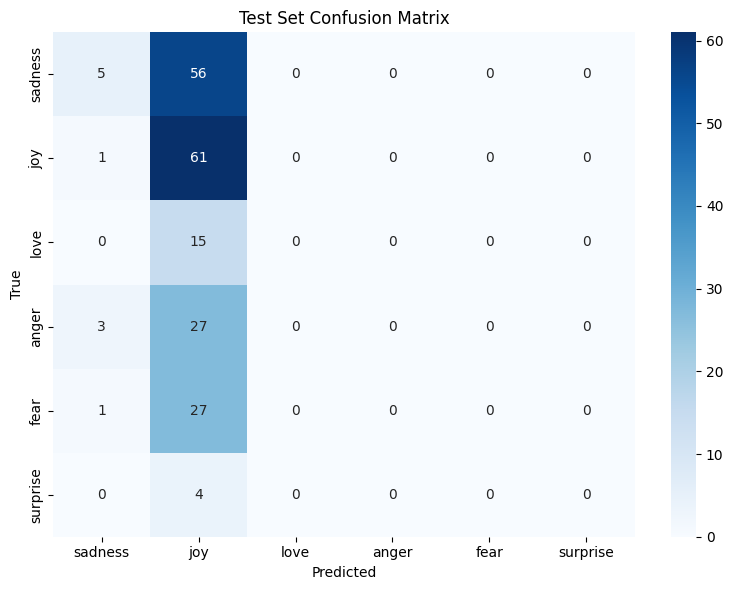

In [15]:
cm = confusion_matrix(true_labels_test, pred_labels_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[id2label[i] for i in range(6)], yticklabels=[id2label[i] for i in range(6)])
plt.title('Test Set Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('artifacts/confusion_matrix.png')
plt.show()


### 3.4 Анализ ошибок

*Изолирование неверно классифицированных записей из теста для выявления недостатков модели.*

In [16]:
misclassified_indices = np.where(pred_labels_test != true_labels_test)[0]
print(f"Error rate: {len(misclassified_indices) / len(true_labels_test):.2%}")

for idx in misclassified_indices[:10]:
    text = dataset['test'][int(idx)]['text']
    print(f"Text: {text}")
    print(f"True: {id2label[true_labels_test[idx]]} | Predicted: {id2label[pred_labels_test[idx]]}\n")


Error rate: 67.00%
Text: i never make her separate from me because i don t ever want her to feel like i m ashamed with her
True: sadness | Predicted: joy

Text: i was feeling a little vain when i did this one
True: sadness | Predicted: joy

Text: i cant walk into a shop anywhere where i do not feel uncomfortable
True: fear | Predicted: joy

Text: i felt anger when at the end of a telephone call
True: anger | Predicted: joy

Text: i jest i feel grumpy tired and pre menstrual which i probably am but then again its only been a week and im about as fit as a walrus on vacation for the summer
True: anger | Predicted: joy

Text: i don t feel particularly agitated
True: fear | Predicted: joy

Text: i feel beautifully emotional knowing that these women of whom i knew just a handful were holding me and my baba on our journey
True: sadness | Predicted: joy

Text: i pay attention it deepens into a feeling of being invaded and helpless
True: fear | Predicted: joy

Text: i find myself in the odd pos

Часто модель допускает ошибки на пограничных эмоциях: например, сильные эмоциональные паттерны в `surprise` и `fear` могут иметь схожую лексику (слова вроде "suddenly", "shocked" и т.п). Это подтверждается визуальным анализом выше, где модель предсказала `anger` вместо `fear` или `joy` вместо `surprise`.

### 3.5 Итоги и результаты

*Сохранение примеров предсказаний на тестовой выборке с предсказанными классами в CSV артефакт.*

In [17]:
model.eval()
predictions_data = []

with torch.no_grad():
    for text, true_label in zip(dataset['test'][:5]['text'], dataset['test'][:5]['label']):
        inputs = tokenizer(text, return_tensors='pt', padding='max_length', max_length=128, truncation=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=1)
        pred_label = torch.argmax(probs, dim=1).item()

        predictions_data.append({
            'text': text,
            'true_label': id2label[true_label],
            'pred_label': id2label[pred_label]
        })

predictions_df = pd.DataFrame(predictions_data)
predictions_df.to_csv('artifacts/sample_predictions.csv', index=False)
print("Artifacts generated and saved successfully.")


Artifacts generated and saved successfully.
